# 딥러닝-성능 최적화: 모델 복잡도

FashionMNIST 데이터를 사용해 CNN 모델의 층 수와 노드 수가 성능에 어떤 영향을 주는지 관찰합니다.

이 노트북의 목표는 다음과 같습니다.

- FashionMNIST 패션 아이템 이미지 10개 클래스를 분류한다.
- convolution filter 수를 바꾸며 성능 변화를 확인한다.
- convolution layer 수를 늘리며 성능 변화를 확인한다.
- 모델이 복잡해질수록 학습 성능과 검증 성능이 어떻게 달라지는지 비교한다.

## 1. 환경 준비

- 필요한 라이브러리를 불러오고, 반복해서 사용할 함수들을 먼저 정의합니다.

### 1.1 라이브러리 불러오기

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [4]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, Subset
from torch.optim import Adam
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor

- 모델 요약 도구
    - `torchsummary`가 설치되어 있으면 CNN 레이어별 출력 크기와 파라미터 수를 확인할 수 있습니다.

In [5]:
# 설치가 필요한 경우 라이브러리 설치합니다.
# %pip install torchsummary

In [6]:
from torchsummary import summary

### 1.2 필요 함수 생성

아래 함수들이 학습 흐름의 핵심입니다.

- `make_DataSet`: numpy/pandas 데이터를 학습용 `DataLoader`와 검증 텐서로 변환합니다.
- `train`: 한 epoch 동안 미니배치 학습을 수행합니다.
- `evaluate`: 검증 또는 테스트 데이터 전체에 대해 손실과 예측값을 반환합니다.
- `dl_learning_curve`: train loss, validation loss, validation accuracy를 시각화합니다.

- `make_DataSet` 함수 : 딥러닝을 위한 데이터로더 만들기

In [7]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size=32):
    """pandas/numpy 데이터를 PyTorch 학습용 DataLoader와 검증 텐서로 변환합니다."""

    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(np.array(x_train), dtype=torch.float32)
    y_train_tensor = torch.tensor(np.array(y_train), dtype=torch.long)
    x_val_tensor = torch.tensor(np.array(x_val), dtype=torch.float32)
    y_val_tensor = torch.tensor(np.array(y_val), dtype=torch.long)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    return train_loader, x_val_tensor, y_val_tensor

- `train` 함수 : 학습을 위한 함수

In [8]:
def train(dataloader, model, loss_fn, optimizer, device):
    """한 epoch 동안 모델을 학습하고 평균 train loss를 반환합니다."""
    model.train()                               # 훈련 모드로 설정
    total_loss = 0

    for x, y in dataloader:                # (x, y) : 입력 데이터와 레이블
        x, y = x.to(device), y.to(device)  # 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 이동

        # Feed Forward
        optimizer.zero_grad()              # 이전 배치의 gradient를 초기화
        pred = model(x)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()                    # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()                   # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트

        total_loss += loss.item() * x.size(0)  # 배치 평균 loss에 배치 크기를 곱해 배치 전체 loss로 누적

    return total_loss / len(dataloader.dataset)  # 전체 데이터 개수로 나누어 epoch 평균 loss 반환

- `evaluate` 함수 : 검증을 위한 함수

In [9]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    """검증/테스트 데이터 전체에 대한 loss와 예측값을 반환합니다."""

    model.eval()  # 모델을 평가 모드로 설정

    with torch.no_grad():  # 평가 과정에서는 기울기를 계산하지 않음
        x = x_val_tensor.to(device)
        y = y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item()

    return eval_loss, pred

- 학습 곡선

In [10]:
def dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list):
    epochs = range(1, len(tr_loss_list) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, tr_loss_list, label="train_loss", marker=".")
    plt.plot(epochs, val_loss_list, label="val_loss", marker=".")
    plt.plot(epochs, val_acc_list, label="val_acc", marker=".")
    plt.xlabel("Epoch")
    plt.ylabel("Loss / Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

- 예측 결과 변환 함수

In [11]:
def predict_class(pred):
    """모델 출력(logits)을 최종 클래스 번호로 변환합니다."""

    pred_prob = nn.functional.softmax(pred, dim=1)
    return np.argmax(pred_prob.cpu().numpy(), axis=1)

### 1.3 Device 준비

GPU가 있으면 GPU를 사용하고, 없으면 CPU를 사용합니다.

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


### 1.4 데이터 셋

- FashionMNIST는 10가지 패션 아이템 이미지 분류 데이터입니다.

    - 입력 데이터: 28 x 28 흑백 이미지
    - 정답 데이터: 패션 아이템 클래스 0 ~ 9
    - 클래스 개수: 10개

![](https://www.researchgate.net/publication/346405197/figure/fig3/AS:962581560848384@1606508736352/Examples-of-Fashion-MNIST-dataset.ppm)

- 데이터 다운로드

In [13]:
train_dataset = datasets.FashionMNIST(root="data", train=True, download=True, transform=ToTensor())
test_dataset = datasets.FashionMNIST(root="data", train=False, download=True, transform=ToTensor())

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.80MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.9MB/s]


- 데이터 축소
    - 여러 모델을 반복 실험하기 위해 학습 데이터 크기를 줄여서 진행합니다.

In [14]:
# 데이터와 레이블 추출
train_data = train_dataset.data.numpy() / 255
train_labels = train_dataset.targets.numpy()
test_data = test_dataset.data.numpy() / 255
test_labels = test_dataset.targets.numpy()

# 데이터 샘플링 : 클래스 비율을 유지하기 위해 stratify 사용
x_train, _, y_train, _ = train_test_split(
    train_data,
    train_labels,
    test_size=40000,
    random_state=10,
    stratify=train_labels
)
x_val, x_test, y_val, y_test = train_test_split(
    test_data,
    test_labels,
    test_size=5000,
    random_state=10,
    stratify=test_labels
)

# 3차원 데이터를 CNN 입력 형태인 4차원으로 변환
x_train = x_train.reshape(20000, 1, 28, 28)
x_val = x_val.reshape(5000, 1, 28, 28)
x_test = x_test.reshape(5000, 1, 28, 28)

# tensor로 변환
x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
x_val = torch.tensor(x_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# train_dataset으로 변환
train_TensorDS = TensorDataset(x_train, y_train)

- 데이터셋의 x와 y

In [15]:
x_train.shape, y_train.shape

(torch.Size([20000, 1, 28, 28]), torch.Size([20000]))

In [16]:
x_val.shape, x_test.shape

(torch.Size([5000, 1, 28, 28]), torch.Size([5000, 1, 28, 28]))

- y(target)의 클래스

In [17]:
classes = train_dataset.classes
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

- train은 DataLoader로 생성

In [18]:
batch_size = 64
train_dataloader = DataLoader(train_TensorDS, batch_size=batch_size, shuffle=True)

In [19]:
# 첫번째 배치만 로딩해서 살펴보기
for x, y in train_dataloader:
    print(f"Shape of x [batch, channels, height, width]: {x.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of x [batch, channels, height, width]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


## 2. 모델링: Simple

- 먼저 가장 단순한 CNN 모델을 만듭니다.

    - convolution filter 수: 4개
    - convolution layer 수: 1개
    - pooling 후 바로 출력층으로 연결

### 2.1 모델 선언

In [20]:
n_class = 10

# 모델 구조 설계
model1 = nn.Sequential(
    nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(4 * 14 * 14, n_class)
).to(device)

# 모델 요약
summary(model1, input_size=(1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 4, 28, 28]              40
              ReLU-2            [-1, 4, 28, 28]               0
         MaxPool2d-3            [-1, 4, 14, 14]               0
           Flatten-4                  [-1, 784]               0
            Linear-5                   [-1, 10]           7,850
Total params: 7,890
Trainable params: 7,890
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.06
Params size (MB): 0.03
Estimated Total Size (MB): 0.09
----------------------------------------------------------------


- Loss function과 Optimizer

In [21]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model1.parameters(), lr=0.001)

### 2.2 모델 학습

Epoch 1, train loss : 0.9123, val loss : 0.5832, val acc : 0.7858
Epoch 2, train loss : 0.5113, val loss : 0.5174, val acc : 0.8058
Epoch 3, train loss : 0.4509, val loss : 0.4548, val acc : 0.8360
Epoch 4, train loss : 0.4177, val loss : 0.4327, val acc : 0.8488
Epoch 5, train loss : 0.3954, val loss : 0.4149, val acc : 0.8516
Epoch 6, train loss : 0.3778, val loss : 0.4109, val acc : 0.8544
Epoch 7, train loss : 0.3651, val loss : 0.3909, val acc : 0.8602
Epoch 8, train loss : 0.3542, val loss : 0.3886, val acc : 0.8616
Epoch 9, train loss : 0.3451, val loss : 0.3942, val acc : 0.8592
Epoch 10, train loss : 0.3372, val loss : 0.3778, val acc : 0.8672


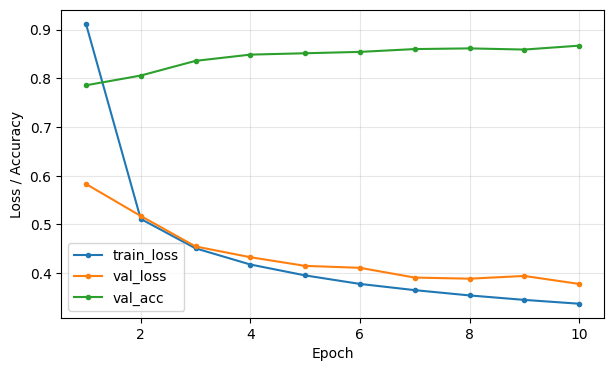

In [22]:
epochs = 10
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model1, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model1, loss_fn, device)

    # accuracy 측정
    pred = predict_class(pred)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)      # train - CrossEntropy
    val_loss_list.append(val_loss)    # val - CrossEntropy
    val_acc_list.append(acc)          # val - Accuracy

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

### 2.3 모델 평가

In [23]:
_, pred = evaluate(x_test, y_test, model1, loss_fn, device)
pred = predict_class(pred)

- confusion matrix

In [24]:
cm = confusion_matrix(y_test.numpy(), pred)
cm

array([[447,   0,   3,  12,   1,   1,  30,   0,   6,   0],
       [  2, 482,   0,  11,   2,   0,   3,   0,   0,   0],
       [ 13,   1, 356,   6,  65,   0,  57,   0,   2,   0],
       [ 15,   9,   4, 432,  19,   0,  21,   0,   0,   0],
       [  0,   1,  27,  11, 420,   1,  38,   0,   2,   0],
       [  0,   0,   0,   1,   0, 475,   0,  16,   0,   8],
       [ 86,   1,  28,  11,  66,   0, 294,   0,  14,   0],
       [  0,   0,   0,   0,   0,   8,   0, 472,   0,  20],
       [  3,   0,   0,   2,   3,   2,   2,   3, 485,   0],
       [  0,   0,   0,   0,   0,   1,   0,  20,   1, 478]])

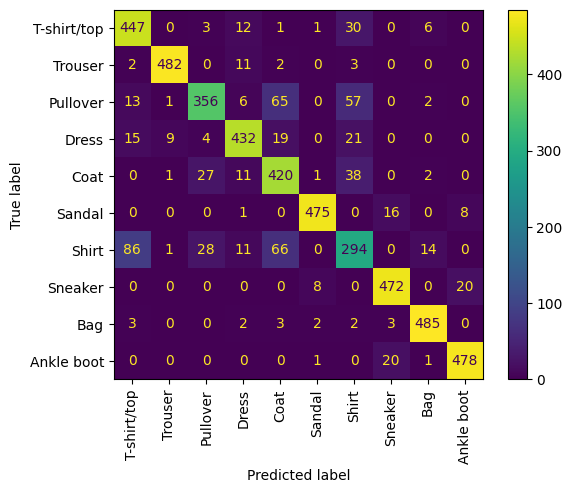

In [25]:
# confusion matrix 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

- classification_report

In [26]:
print(accuracy_score(y_test.numpy(), pred))
print("-" * 100)
print(classification_report(y_test.numpy(), pred, target_names=classes))

0.8682
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.79      0.89      0.84       500
     Trouser       0.98      0.96      0.97       500
    Pullover       0.85      0.71      0.78       500
       Dress       0.89      0.86      0.88       500
        Coat       0.73      0.84      0.78       500
      Sandal       0.97      0.95      0.96       500
       Shirt       0.66      0.59      0.62       500
     Sneaker       0.92      0.94      0.93       500
         Bag       0.95      0.97      0.96       500
  Ankle boot       0.94      0.96      0.95       500

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000



---

## 3. 모델링 실험 1: Node

- 모델 구조는 그대로 두고 노드(커널) 수만 늘려 봅니다.
- nn.Conv2d(1, `n`, ...)
    - `n`을 늘리면 더 다양한 특징을 추출할 수 있지만, 파라미터 수와 연산량도 함께 증가

### 3.1 모델 선언

In [27]:
n_class = 10
n = 32

# 모델 구조 설계
model2 = nn.Sequential(
    nn.Conv2d(1, n, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(n * 14 * 14, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model2.parameters(), lr=0.001)

summary(model2, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
         MaxPool2d-3           [-1, 32, 14, 14]               0
           Flatten-4                 [-1, 6272]               0
            Linear-5                   [-1, 10]          62,730
Total params: 63,050
Trainable params: 63,050
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.48
Params size (MB): 0.24
Estimated Total Size (MB): 0.72
----------------------------------------------------------------


### 3.2 모델 학습

Epoch 1, train loss : 0.5786, val loss : 0.4314, val acc : 0.8502
Epoch 2, train loss : 0.3687, val loss : 0.3904, val acc : 0.8598
Epoch 3, train loss : 0.3276, val loss : 0.3735, val acc : 0.8696
Epoch 4, train loss : 0.2955, val loss : 0.3418, val acc : 0.8828
Epoch 5, train loss : 0.2753, val loss : 0.3385, val acc : 0.8834
Epoch 6, train loss : 0.2555, val loss : 0.3320, val acc : 0.8810
Epoch 7, train loss : 0.2451, val loss : 0.3321, val acc : 0.8846
Epoch 8, train loss : 0.2289, val loss : 0.3258, val acc : 0.8838
Epoch 9, train loss : 0.2158, val loss : 0.3194, val acc : 0.8866
Epoch 10, train loss : 0.2091, val loss : 0.3446, val acc : 0.8738


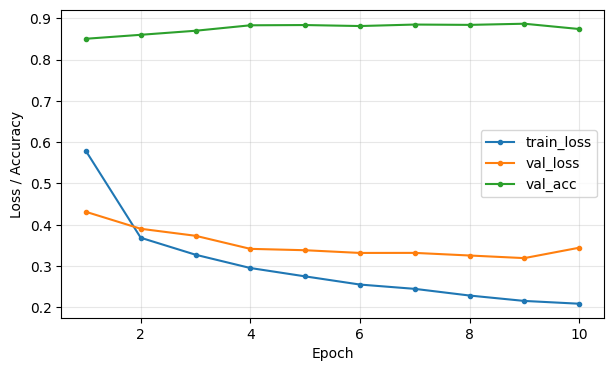

In [28]:
epochs = 10
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model2, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model2, loss_fn, device)

    # accuracy 측정
    pred = predict_class(pred)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)             # train - CrossEntropy
    val_loss_list.append(val_loss)           # val - CrossEntropy
    val_acc_list.append(acc)                 # val - Accuracy

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

### 3.3 모델 평가

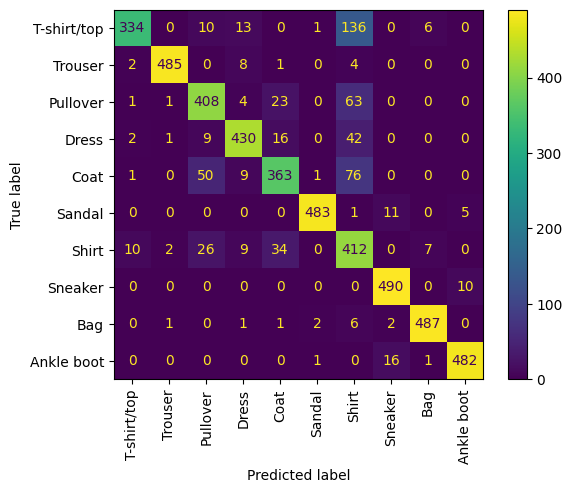

Accuracy : 0.8748
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.95      0.67      0.79       500
     Trouser       0.99      0.97      0.98       500
    Pullover       0.81      0.82      0.81       500
       Dress       0.91      0.86      0.88       500
        Coat       0.83      0.73      0.77       500
      Sandal       0.99      0.97      0.98       500
       Shirt       0.56      0.82      0.66       500
     Sneaker       0.94      0.98      0.96       500
         Bag       0.97      0.97      0.97       500
  Ankle boot       0.97      0.96      0.97       500

    accuracy                           0.87      5000
   macro avg       0.89      0.87      0.88      5000
weighted avg       0.89      0.87      0.88      5000



In [29]:
# 예측
_, pred = evaluate(x_test, y_test, model2, loss_fn, device)
pred = predict_class(pred)

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print("=" * 80)
print(f"Accuracy : {accuracy_score(y_test.numpy(), pred)}")
print("-" * 80)
print(classification_report(y_test.numpy(), pred, target_names=classes))

### 3.4 [참조] 함수로 생성해서 테스트

- filter 수를 여러 값으로 바꾸며 반복 실험합니다.
- 실행 시간이 오래 걸릴 수 있습니다.

In [30]:
def make_model(node, epochs=10):

    # 모델 구조 설계
    model = nn.Sequential(
        nn.Conv2d(1, node, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Flatten(),
        nn.Linear(node * 14 * 14, 10)
    ).to(device)

    # loss, optimizer
    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=0.001)

    # 학습
    for t in range(epochs):
        tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)

    # 예측 및 평가
    _, pred = evaluate(x_test, y_test, model, loss_fn, device)
    pred = predict_class(pred)

    return accuracy_score(y_test.numpy(), pred)

In [31]:
# 5부터 100까지 5씩 증가시켜가며 모델링 및 성능 테스트
acc = []
for n in range(5, 101, 5):
    acc.append(make_model(n))
    print(n)

5
10
15
20
25
30
35
40
45
50
55
60
65
70
75
80
85
90
95
100


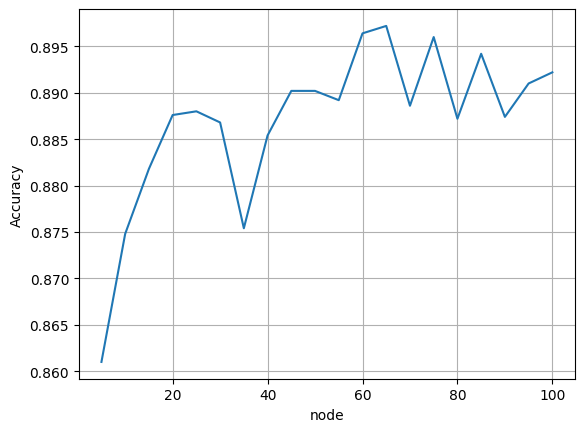

In [32]:
plt.plot(range(5, 101, 5), acc)
plt.xlabel("node")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

---

## 4. 모델링 실험 2: Layer

- 이번에는 convolution layer 수를 늘려 봅니다.
- layer 수가 늘어나면 더 복잡한 패턴을 학습할 수 있지만, 데이터와 학습 조건에 따라 과적합이나 학습 시간 증가가 발생할 수 있습니다.

### 4.1 Conv2d 2개

#### 4.1.1 모델 선언

In [34]:
n_class = 10

# 모델 구조 설계
model3 = nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 7 * 7, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model3.parameters(), lr=0.001)

summary(model3, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 8, 28, 28]              80
              ReLU-2            [-1, 8, 28, 28]               0
         MaxPool2d-3            [-1, 8, 14, 14]               0
            Conv2d-4           [-1, 16, 14, 14]           1,168
              ReLU-5           [-1, 16, 14, 14]               0
         MaxPool2d-6             [-1, 16, 7, 7]               0
           Flatten-7                  [-1, 784]               0
            Linear-8                   [-1, 10]           7,850
Total params: 9,098
Trainable params: 9,098
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.17
Params size (MB): 0.03
Estimated Total Size (MB): 0.21
----------------------------------------------------------------


#### 4.1.2 모델 학습

Epoch 1, train loss : 0.8010, val loss : 0.5778, val acc : 0.7878
Epoch 2, train loss : 0.4962, val loss : 0.4926, val acc : 0.8232
Epoch 3, train loss : 0.4415, val loss : 0.4624, val acc : 0.8322
Epoch 4, train loss : 0.4067, val loss : 0.4264, val acc : 0.8486
Epoch 5, train loss : 0.3874, val loss : 0.4097, val acc : 0.8508
Epoch 6, train loss : 0.3716, val loss : 0.3906, val acc : 0.8598
Epoch 7, train loss : 0.3592, val loss : 0.3980, val acc : 0.8564
Epoch 8, train loss : 0.3511, val loss : 0.3880, val acc : 0.8562
Epoch 9, train loss : 0.3373, val loss : 0.4001, val acc : 0.8516
Epoch 10, train loss : 0.3318, val loss : 0.3643, val acc : 0.8706
Epoch 11, train loss : 0.3226, val loss : 0.3704, val acc : 0.8664
Epoch 12, train loss : 0.3128, val loss : 0.3580, val acc : 0.8726
Epoch 13, train loss : 0.3022, val loss : 0.3456, val acc : 0.8778
Epoch 14, train loss : 0.3000, val loss : 0.4089, val acc : 0.8484
Epoch 15, train loss : 0.2938, val loss : 0.3406, val acc : 0.8786
Epoc

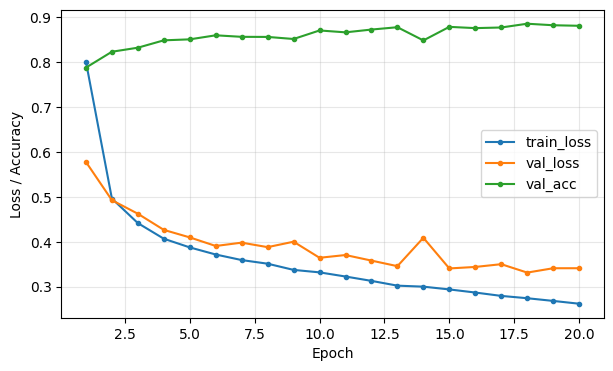

In [35]:
epochs = 20
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model3, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model3, loss_fn, device)

    # accuracy 측정
    pred = predict_class(pred)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    val_acc_list.append(acc)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

#### 4.1.3 모델 평가

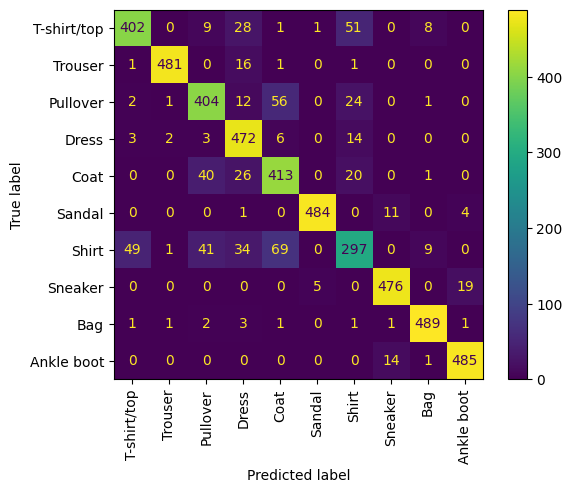

Accuracy : 0.8806
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.88      0.80      0.84       500
     Trouser       0.99      0.96      0.98       500
    Pullover       0.81      0.81      0.81       500
       Dress       0.80      0.94      0.86       500
        Coat       0.76      0.83      0.79       500
      Sandal       0.99      0.97      0.98       500
       Shirt       0.73      0.59      0.65       500
     Sneaker       0.95      0.95      0.95       500
         Bag       0.96      0.98      0.97       500
  Ankle boot       0.95      0.97      0.96       500

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



In [36]:
# 예측
_, pred = evaluate(x_test, y_test, model3, loss_fn, device)
pred = predict_class(pred)

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print("=" * 80)
print(f"Accuracy : {accuracy_score(y_test.numpy(), pred)}")
print("-" * 80)
print(classification_report(y_test.numpy(), pred, target_names=classes))

### 4.2 Conv2d 3개

#### 4.2.1 모델 선언

In [37]:
n_class = 10

# 모델 구조 설계
model4 = nn.Sequential(
    nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(4, 8, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 3 * 3, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model4.parameters(), lr=0.001)

summary(model4, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 4, 28, 28]              40
              ReLU-2            [-1, 4, 28, 28]               0
         MaxPool2d-3            [-1, 4, 14, 14]               0
            Conv2d-4            [-1, 8, 14, 14]             296
              ReLU-5            [-1, 8, 14, 14]               0
         MaxPool2d-6              [-1, 8, 7, 7]               0
            Conv2d-7             [-1, 16, 7, 7]           1,168
              ReLU-8             [-1, 16, 7, 7]               0
         MaxPool2d-9             [-1, 16, 3, 3]               0
          Flatten-10                  [-1, 144]               0
           Linear-11                   [-1, 10]           1,450
Total params: 2,954
Trainable params: 2,954
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/back

#### 4.2.2 모델 학습

Epoch 1, train loss : 1.1057, val loss : 0.7418, val acc : 0.7334
Epoch 2, train loss : 0.6821, val loss : 0.6525, val acc : 0.7610
Epoch 3, train loss : 0.6033, val loss : 0.6212, val acc : 0.7704
Epoch 4, train loss : 0.5518, val loss : 0.5632, val acc : 0.7892
Epoch 5, train loss : 0.5165, val loss : 0.5497, val acc : 0.7968
Epoch 6, train loss : 0.4872, val loss : 0.5114, val acc : 0.8150
Epoch 7, train loss : 0.4668, val loss : 0.4962, val acc : 0.8202
Epoch 8, train loss : 0.4435, val loss : 0.4827, val acc : 0.8220
Epoch 9, train loss : 0.4295, val loss : 0.4625, val acc : 0.8328
Epoch 10, train loss : 0.4174, val loss : 0.4490, val acc : 0.8360
Epoch 11, train loss : 0.4066, val loss : 0.4416, val acc : 0.8380
Epoch 12, train loss : 0.3998, val loss : 0.4395, val acc : 0.8380
Epoch 13, train loss : 0.3855, val loss : 0.4355, val acc : 0.8398
Epoch 14, train loss : 0.3816, val loss : 0.4294, val acc : 0.8444
Epoch 15, train loss : 0.3750, val loss : 0.4261, val acc : 0.8464
Epoc

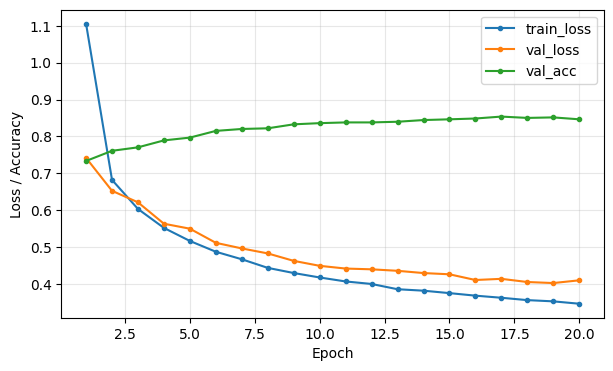

In [39]:
epochs = 20
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model4, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model4, loss_fn, device)

    # accuracy 측정
    pred = predict_class(pred)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    val_acc_list.append(acc)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

#### 4.2.3 모델 평가

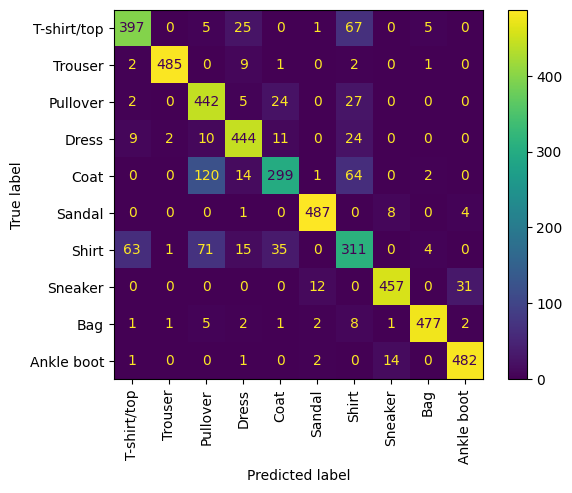

Accuracy : 0.8562
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.79      0.81       500
     Trouser       0.99      0.97      0.98       500
    Pullover       0.68      0.88      0.77       500
       Dress       0.86      0.89      0.87       500
        Coat       0.81      0.60      0.69       500
      Sandal       0.96      0.97      0.97       500
       Shirt       0.62      0.62      0.62       500
     Sneaker       0.95      0.91      0.93       500
         Bag       0.98      0.95      0.96       500
  Ankle boot       0.93      0.96      0.95       500

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000



In [40]:
# 예측
_, pred = evaluate(x_test, y_test, model4, loss_fn, device)
pred = predict_class(pred)

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print("=" * 80)
print(f"Accuracy : {accuracy_score(y_test.numpy(), pred)}")
print("-" * 80)
print(classification_report(y_test.numpy(), pred, target_names=classes))

### 4.3 실습

- `4.2` 모델에서 Dense Layer(`nn.Linear`) 수와 노드 수를 조정하며 성능을 확인해 봅니다.

#### 4.3.1 모델 선언

In [42]:
n_class = 10

# 모델 구조 설계
model5 = nn.Sequential(
    nn.Conv2d(1, 2, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(2, 4, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(4, 8, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(8 * 3 * 3, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model5.parameters(), lr=0.001)

summary(model5, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 2, 28, 28]              20
              ReLU-2            [-1, 2, 28, 28]               0
         MaxPool2d-3            [-1, 2, 14, 14]               0
            Conv2d-4            [-1, 4, 14, 14]              76
              ReLU-5            [-1, 4, 14, 14]               0
         MaxPool2d-6              [-1, 4, 7, 7]               0
            Conv2d-7              [-1, 8, 7, 7]             296
              ReLU-8              [-1, 8, 7, 7]               0
         MaxPool2d-9              [-1, 8, 3, 3]               0
          Flatten-10                   [-1, 72]               0
           Linear-11                   [-1, 10]             730
Total params: 1,122
Trainable params: 1,122
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/back

#### 4.3.2 모델 학습

Epoch 1, train loss : 1.3149, val loss : 0.8962, val acc : 0.6588
Epoch 2, train loss : 0.7955, val loss : 0.7861, val acc : 0.6992
Epoch 3, train loss : 0.7140, val loss : 0.7359, val acc : 0.7272
Epoch 4, train loss : 0.6618, val loss : 0.6791, val acc : 0.7580
Epoch 5, train loss : 0.6223, val loss : 0.6375, val acc : 0.7674
Epoch 6, train loss : 0.5947, val loss : 0.6122, val acc : 0.7754
Epoch 7, train loss : 0.5717, val loss : 0.5977, val acc : 0.7798
Epoch 8, train loss : 0.5561, val loss : 0.5738, val acc : 0.7954
Epoch 9, train loss : 0.5401, val loss : 0.5858, val acc : 0.7908
Epoch 10, train loss : 0.5360, val loss : 0.5670, val acc : 0.7970
Epoch 11, train loss : 0.5195, val loss : 0.5624, val acc : 0.7980
Epoch 12, train loss : 0.5120, val loss : 0.5779, val acc : 0.7940
Epoch 13, train loss : 0.5069, val loss : 0.5704, val acc : 0.7984
Epoch 14, train loss : 0.5024, val loss : 0.5308, val acc : 0.8138
Epoch 15, train loss : 0.4944, val loss : 0.5162, val acc : 0.8190
Epoc

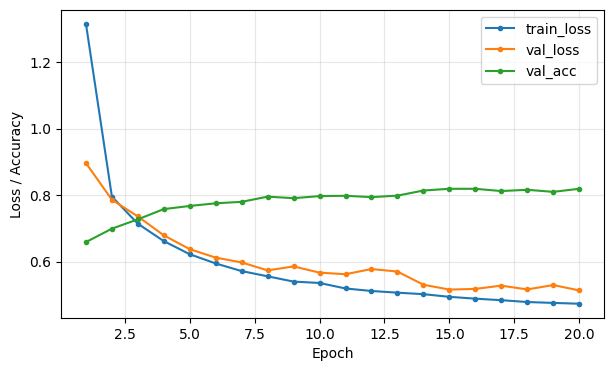

In [43]:
epochs = 20
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model5, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model5, loss_fn, device)

    # accuracy 측정
    pred = predict_class(pred)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    val_acc_list.append(acc)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

#### 4.3.3 모델 평가

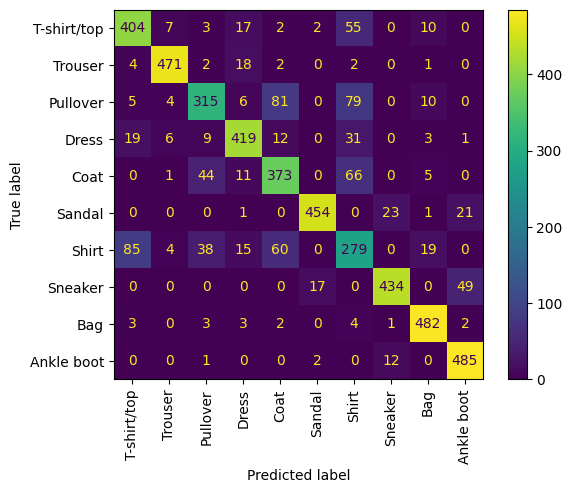

Accuracy : 0.8232
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.78      0.81      0.79       500
     Trouser       0.96      0.94      0.95       500
    Pullover       0.76      0.63      0.69       500
       Dress       0.86      0.84      0.85       500
        Coat       0.70      0.75      0.72       500
      Sandal       0.96      0.91      0.93       500
       Shirt       0.54      0.56      0.55       500
     Sneaker       0.92      0.87      0.89       500
         Bag       0.91      0.96      0.94       500
  Ankle boot       0.87      0.97      0.92       500

    accuracy                           0.82      5000
   macro avg       0.82      0.82      0.82      5000
weighted avg       0.82      0.82      0.82      5000



In [44]:
# 예측
_, pred = evaluate(x_test, y_test, model5, loss_fn, device)
pred = predict_class(pred)

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print("=" * 80)
print(f"Accuracy : {accuracy_score(y_test.numpy(), pred)}")
print("-" * 80)
print(classification_report(y_test.numpy(), pred, target_names=classes))